In [1]:
import pandas as pd

df = pd.read_csv("../data/HHS_Unaccompanied_Alien_Children_Program.csv")

print(df.head())
print(df.shape)
print(df.columns)
print(df.info())

                Date  Children apprehended and placed in CBP custody*  \
0  December 21, 2025                                              6.0   
1  December 18, 2025                                             11.0   
2  December 17, 2025                                              7.0   
3  December 16, 2025                                              8.0   
4  December 15, 2025                                             11.0   

   Children in CBP custody  Children transferred out of CBP custody  \
0                     18.0                                     11.0   
1                     50.0                                      6.0   
2                     31.0                                     11.0   
3                     54.0                                     15.0   
4                     42.0                                      9.0   

  Children in HHS Care  Children discharged from HHS Care  
0                2,484                               14.0  
1             

In [2]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Check the data types again
print(df.dtypes)

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

Date                                               datetime64[us]
Children apprehended and placed in CBP custody*           float64
Children in CBP custody                                   float64
Children transferred out of CBP custody                   float64
Children in HHS Care                                          str
Children discharged from HHS Care                         float64
dtype: object

Missing values:
Date                                               450
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64


In [3]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Remove completely empty rows
df = df.dropna(how="all")

# Sort data by date
df = df.sort_values("Date")

# Reset the index
df = df.reset_index(drop=True)

# Check the cleaned dataset
print("Dataset shape:", df.shape)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (720, 6)

Missing values after cleaning:
Date                                               0
Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64

Data types:
Date                                               datetime64[us]
Children apprehended and placed in CBP custody*           float64
Children in CBP custody                                   float64
Children transferred out of CBP custody                   float64
Children in HHS Care                                          str
Children discharged from HHS Care                         float64
dtype: object

First 5 rows:


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2023-01-12,33.0,53.0,34.0,"6,566",436.0
1,2023-01-22,32.0,49.0,39.0,"7,122",227.0
2,2023-01-23,32.0,50.0,39.0,"7,280",181.0
3,2023-01-24,47.0,42.0,47.0,"7,433",175.0
4,2023-01-25,20.0,22.0,41.0,"7,538",180.0


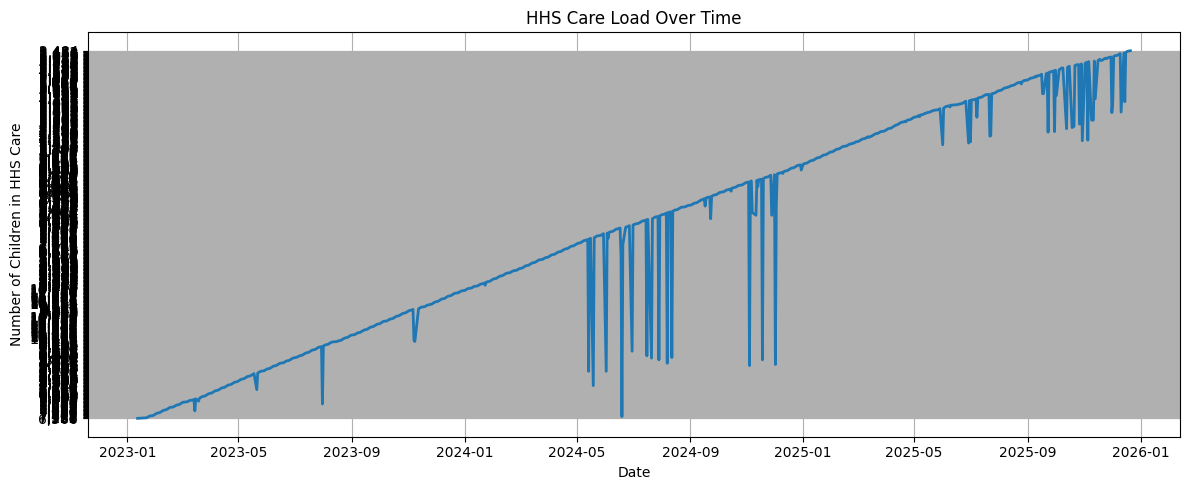

In [4]:
import matplotlib.pyplot as plt

# Plot HHS care load over time
plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"],
    df["Children in HHS Care"],
    linewidth=2
)

plt.title("HHS Care Load Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Children in HHS Care")
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
# Select numerical columns
numeric_cols = [
    "Children apprehended and placed in CBP custody*",
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children in HHS Care",
    "Children discharged from HHS Care"
]

# Remove commas and convert values to numbers
corr_data = df[numeric_cols].replace(",", "", regex=True)

for column in numeric_cols:
    corr_data[column] = pd.to_numeric(
        corr_data[column], errors="coerce"
    )

# Calculate correlation
correlation = corr_data.corr()

# Display correlation with HHS Care
print("Correlation with Children in HHS Care:")
print(
    correlation["Children in HHS Care"]
    .sort_values(ascending=False)
)

Correlation with Children in HHS Care:
Children in HHS Care                               1.000000
Children discharged from HHS Care                  0.920881
Children transferred out of CBP custody            0.713899
Children apprehended and placed in CBP custody*    0.691312
Children in CBP custody                            0.663662
Name: Children in HHS Care, dtype: float64


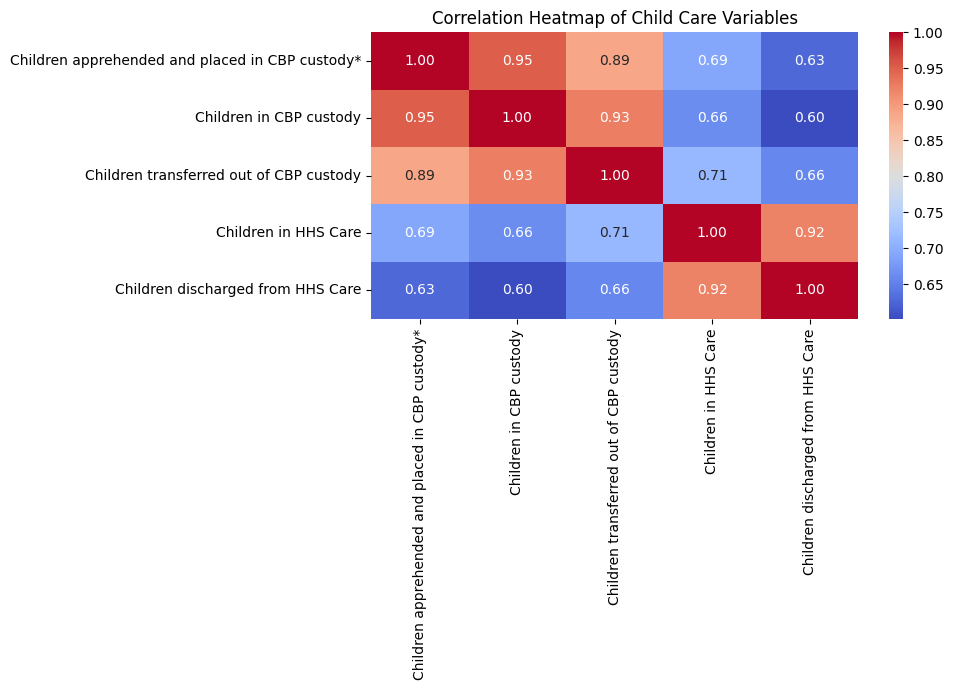

In [12]:
# Correlation heatmap

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Child Care Variables")
plt.tight_layout()
plt.show()

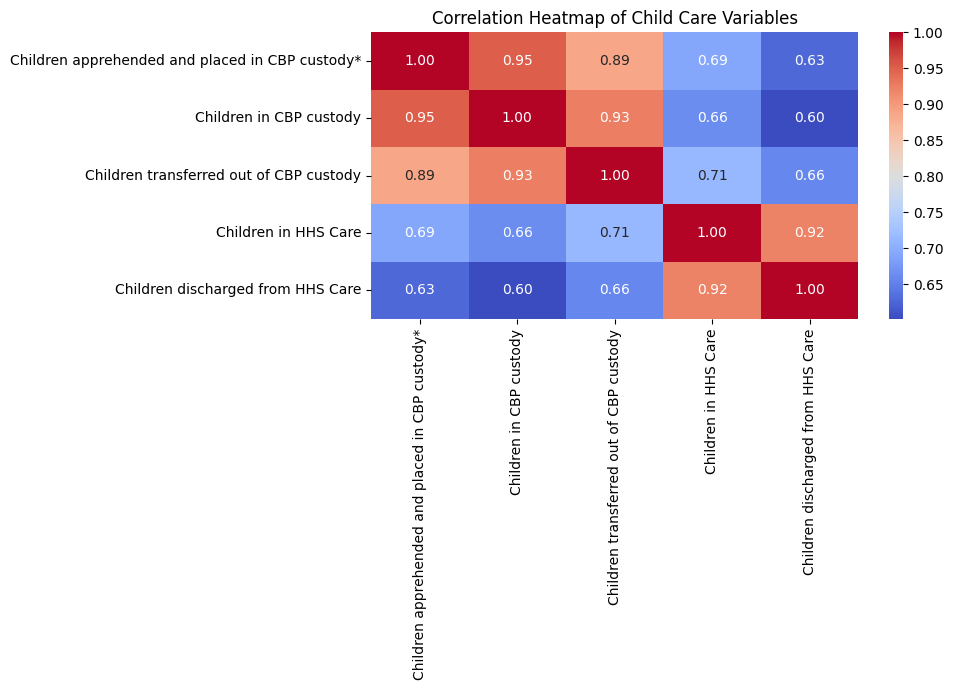

In [13]:
# Save correlation heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Child Care Variables")
plt.tight_layout()

plt.savefig("../outputs/correlation_heatmap.png", dpi=300)
plt.show()